In [4]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import numpy as np
import math
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [8]:
class Model(nn.Module):
    def __init__(self, infeatures, out_features):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(infeatures, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 256)
        self.fc4 = nn.Linear(256, 512)
        self.fc5 = nn.Linear(512, 512)
        self.fc6 = nn.Linear(512, 256)
        self.fc7 = nn.Linear(256, 256)
        self.fc8 = nn.Linear(256, 256)
        self.fc9 = nn.Linear(256, 64)
        self.fc10 = nn.Linear(64, 64)
        self.fc11 = nn.Linear(64, 16)
        self.out = nn.Linear(16, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = F.relu(self.fc6(x))
        x = F.relu(self.fc7(x))
        x = F.relu(self.fc8(x))
        x = F.relu(self.fc9(x))
        x = F.relu(self.fc10(x))
        x = F.relu(self.fc11(x))
        x = self.out(x)
        return x

In [9]:
class ImageDataloadr(Dataset):
    def __init__(self):
        path = "/home/adminnio/Downloads/splat-image 1.png"
        
        # Load and resize image
        image = Image.open(path).convert('RGB')
        image = image.resize((32, 32))  # Resize before converting to NumPy
        image_np = np.array(image).astype(np.float32)   # Normalize to [0, 1]

        # Get height and width
        self.height, self.width, _ = image_np.shape

        # Create coordinate grid
        rows, cols = np.meshgrid(np.arange(self.height), np.arange(self.width), indexing='ij')
        self.coords = np.stack((rows, cols), axis=-1).reshape(-1, 2).astype(np.float32)
        self.rgb_values = image_np.reshape(-1, 3).astype(np.float32)
        self.n_samples = self.height * self.width

    def __getitem__(self, index):
        coord = torch.tensor(self.coords[index], dtype=torch.float32)
        rgb = torch.tensor(self.rgb_values[index], dtype=torch.float32)
        return coord, rgb

    def __len__(self):
        return self.n_samples


In [12]:
dataset = ImageDataloadr()
dataloader = DataLoader(dataset=dataset, batch_size=1024, shuffle=True,num_workers=0)
dataiter = iter(dataloader)
data = next(dataiter)
f,l =data

#print(l)

In [13]:



def visualize_learned_image(model, height, width, device):
    # Create a mesh grid of pixel coordinates (0 to height-1, 0 to width-1)
    coords = torch.stack(torch.meshgrid(torch.arange(height), torch.arange(width), indexing='ij'), dim=-1)
    coords = coords.reshape(-1, 2).to(torch.float32).to(device)

    coords_norm = coords / torch.tensor([height - 1, width - 1], dtype=torch.float32).to(device)

    with torch.no_grad():
        output = model(coords)

    # Since the model outputs values in the range [0, 255], we scale them to [0, 1]
    rgb = (output / 255.0).clamp(0, 1).reshape(height, width, 3).cpu().numpy()

    # Plot the learned image
    plt.imshow(rgb)
    plt.title("Learned Image")
    plt.axis('off')
    plt.show()
    
def visualize_learned_image_encoded(model, height, width, device, L=10):
    coords = torch.stack(torch.meshgrid(torch.arange(height), torch.arange(width), indexing='ij'), dim=-1)
    coords = coords.reshape(-1, 2).to(torch.float32).to(device)

    # Normalize coordinates to [0, 1] for model input
    #coords_norm = coords / torch.tensor([height - 1, width - 1], dtype=torch.float32).to(device)

    # Perform forward pass to predict RGB values for each pixel
    with torch.no_grad():
        output = model(coords)

    # Since the model outputs values in the range [0, 255], we scale them to [0, 1]
    rgb = (output / 255.0).clamp(0, 1).reshape(height, width, 3).cpu().numpy()

    # Plot the learned image
    plt.imshow(rgb)
    plt.title("Learned Image")
    plt.axis('off')
    plt.show()
  



def get_img(model, height, width, device):
    image = np.zeros((height, width, 3), dtype=np.float32)

    for i in range(height):
        for j in range(width):
           
            # Create input tensor and move to device
            input_tensor = torch.tensor([[i, j]], dtype=torch.float32).to(device)

            with torch.no_grad():
                rgb = model(input_tensor).cpu().numpy()[0]  # Get output as numpy array

            # Normalize from [0, 255] to [0, 1] if needed
            #rgb = np.clip(rgb / 255.0, 0, 1)
            image[i, j] = rgb

    # # Display the image
    # plt.imshow(image)
    # plt.title("Pixel-wise Learned Image")
    # plt.axis('off')
    # plt.show()
    return image

Total Training Progress:   0%|          | 0/10000 [00:00<?, ?it/s, loss=9.72e+3]

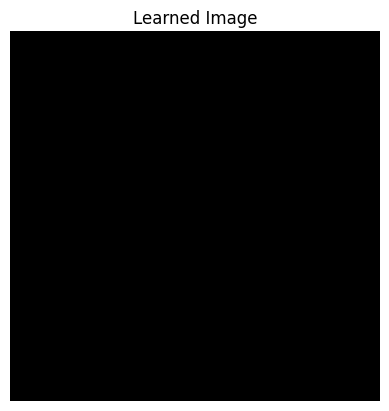

Total Training Progress:   5%|▏  | 500/10000 [00:03<00:54, 173.12it/s, loss=501]

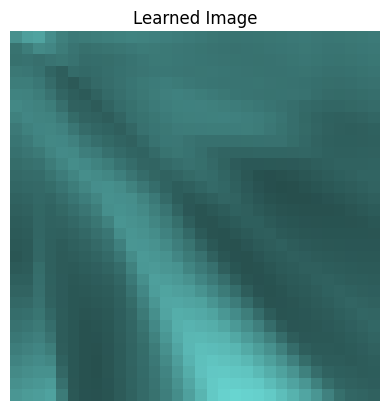

Total Training Progress:  10%|▏ | 1000/10000 [00:06<00:56, 158.05it/s, loss=416]

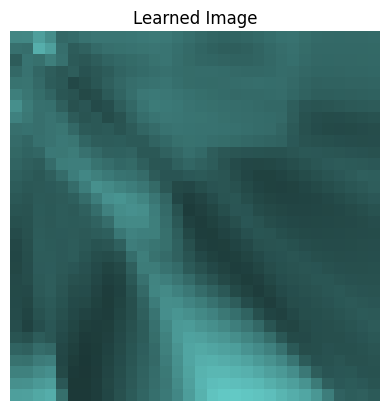

Total Training Progress:  15%|▎ | 1500/10000 [00:09<00:47, 180.33it/s, loss=314]

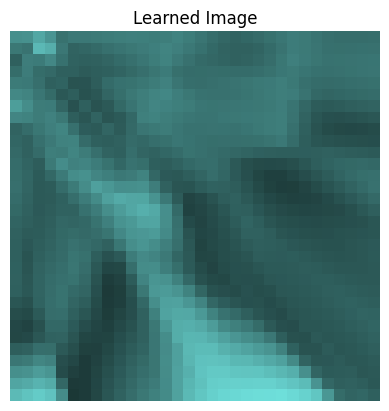

Total Training Progress:  20%|▍ | 2000/10000 [00:12<00:44, 178.21it/s, loss=428]

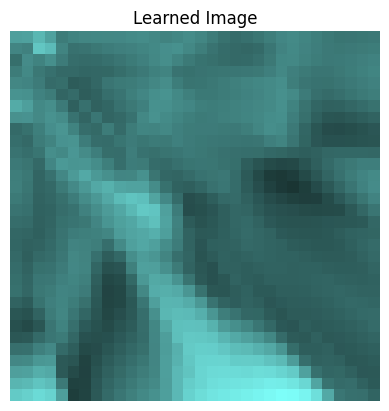

Total Training Progress:  20%|▍ | 2048/10000 [00:12<00:48, 163.38it/s, loss=282]


KeyboardInterrupt: 

In [14]:
from tqdm import tqdm
import torch.nn as nn

total_batches = 10
epochs = 10000 
model = Model(infeatures=2, out_features=3).to(device)
criterion = nn.MSELoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
batches_per_epoch = len(dataloader)
total_steps = epochs * batches_per_epoch  
with tqdm(total=total_steps, desc="Total Training Progress") as pbar:
    for epoch in range(epochs):
        for features, labels in dataloader:
            features = features.to(torch.float32).to(device)
            labels = labels.to(torch.float32).to(device)

            # Forward pass
            scores = model(features)
            loss = criterion(scores, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Update the single global progress bar
            pbar.set_postfix(loss=loss.item())
            pbar.update(1)

    # Optionally visualize or log things here every N epochs
        if epoch % 500 == 0:
            with torch.no_grad():
                output = model(features)
                visualize_learned_image(model, dataloader.dataset.height, dataloader.dataset.width, device=device)


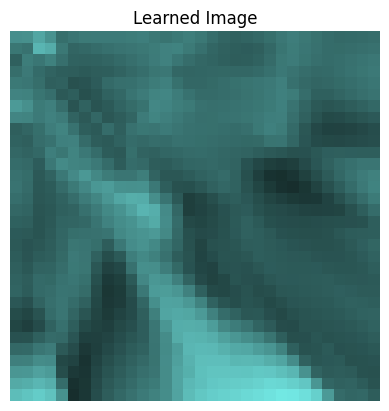

In [15]:
with torch.no_grad():
     output = model(features)
     visualize_learned_image(model, dataloader.dataset.height, dataloader.dataset.width, device=device)
